# Assignment 5 - Idea Research: Weekly Mean Reversion in Swiss Equities

## Objective

This notebook is the **signal research and selection** component of the assignment. It investigates whether short-horizon cross-sectional reversal provides a credible predictive signal in Swiss equities during the development period from **January 2010 through December 2019**.

The central hypothesis is that securities with unusually poor performance during a completed week may partially rebound relative to recent winners during the following week. Three economically motivated definitions of reversal are compared:

1. raw weekly reversal;
2. volatility-scaled weekly reversal;
3. market-residual volatility-scaled reversal.

The analysis concludes by selecting and freezing one score for implementation in the companion backtesting notebook. That separate notebook evaluates the fixed portfolio strategy beginning in **January 2020**; liquidity filters, portfolio optimization, constraints, SPI benchmarking, and final investable performance are intentionally outside the scope of this research notebook.


## Economic Motivation And Hypothesis

Short-term reversal may arise when temporary liquidity shocks, non-informational trading pressure, or short-lived investor overreaction push individual security prices away from their short-run equilibrium values. If this effect subsequently unwinds, recent weekly losers should outperform recent weekly winners over the following week.

Raw reversal may mechanically favour securities that experienced large price moves simply because they are highly volatile. Volatility scaling is therefore considered to identify underperformance relative to a stock's recent risk level. A market-residual specification is also studied to determine whether reversal persists after removing broad market movements.

The predictive hypothesis, to be tested later in this report, is:

$$
H_1:
\quad
\rho_S\left(s_{i,t}, R^W_{i,t+1}\right) > 0,
$$

where $\rho_S$ is the cross-sectional Spearman rank correlation, $s_{i,t}$ is a reversal score formed at the end of week $t$, and $R^W_{i,t+1}$ is the subsequent weekly return.


## Research Design

The development-stage workflow is deliberately sequential:

```text
Historical daily market data
-> construct weekly reversal candidates
-> evaluate signal relationships during 2010-2019
-> test predictive evidence during 2010-2019
-> assess diagnostic implementation feasibility during 2010-2019
-> freeze one selected signal
-> implement and evaluate it from 2020 onward in the backtesting notebook
```

This notebook performs signal research rather than final portfolio backtesting. The long-short spreads reported below are transparent diagnostic portfolios used to measure the economic content and turnover pressure of the candidate scores. SPI benchmarking, Black-Litterman portfolio construction, implementation constraints, and final strategy results are reserved for the companion backtesting notebook.


## Data And Initial Quality Review

The analysis uses daily Swiss equity prices from `market_data.parquet` and daily SPI returns from `spi_index.csv`. The market index is needed only for constructing the market-residual signal.

Prices are converted to a date-by-security matrix. Missing prices are **not** forward-filled before computing returns: doing so would generate artificial zero returns and could distort a short-horizon reversal study. Duplicate stock-date records are resolved explicitly before reshaping the data.

Large daily price movements are flagged, rather than silently removed. They may reflect genuine corporate events or data-adjustment issues and will be revisited later in a sensitivity analysis before a final signal decision is made.


## Daily And Weekly Return Construction

Let $P_{i,d}$ denote the observed closing price of security $i$ on day $d$. The daily close-to-close return is

$$
r^D_{i,d}
=
\frac{P_{i,d}}{P_{i,d-1}}-1.
$$

Daily returns are compounded to a weekly horizon:

$$
R^W_{i,t}
=
\prod_{d \in \mathcal{W}(t)}(1+r^D_{i,d})-1.
$$

A minimum number of valid daily observations is required within a week. The score dated at the end of week $t$ uses information available through that completed week and is evaluated against returns during week $t+1$:

$$
s_{i,t} \longrightarrow R^W_{i,t+1}.
$$

| Stage | Information Available | Research Use |
| --- | --- | --- |
| End of week $t$ | Completed weekly return and historical volatility | Construct score |
| Week $t+1$ | Subsequent realized return | Evaluate prediction |

No additional weekly lag is required for this research definition. This timing is also consistent with the later course-framework implementation, in which a portfolio formed on a rebalance date begins earning returns only after that date.

Only observations for which both the formation week and the subsequent outcome week fall within the **2010-2019 development period** are used to select the signal. Consequently, a score formed in the final week of December 2019 is excluded if its realized one-week-ahead return belongs to January 2020.


## Candidate Reversal Scores

All three scores use a common sign convention:

$$
\text{higher score}
=
\text{larger recent underperformance}
=
\text{stronger rebound candidate}.
$$

### Raw Reversal

$$
s^{raw}_{i,t} = -R^W_{i,t}.
$$

This is the most direct expression of the hypothesis: stocks that lost more during the most recent week receive higher scores.

### Volatility-Scaled Reversal

$$
s^{vol}_{i,t}
=
-\frac{R^W_{i,t}}{\sigma^W_{i,t}},
\qquad
\sigma^W_{i,t}=Std\left(R^W_{i,t-51},\ldots,R^W_{i,t}\right).
$$

This is the central candidate idea because it measures recent underperformance relative to the security's own trailing weekly volatility.

### Market-Residual Volatility-Scaled Reversal

A lagged market beta is estimated from daily observations:

$$
\widehat{\beta}_{i,d-1}
=
\frac{Cov_{d-1}(r^D_i,r^{SPI})}{Var_{d-1}(r^{SPI})}.
$$

Residual daily returns are defined as

$$
r^{res,D}_{i,d}
=
r^D_{i,d}-\widehat{\beta}_{i,d-1}r^{SPI}_{d},
$$

and are then compounded to form residual weekly returns. The residual reversal score is

$$
s^{res}_{i,t}
=
-\frac{R^{res,W}_{i,t}}{\sigma^{res,W}_{i,t}}.
$$

This specification asks whether stock-specific recent underperformance, rather than broad market movement, predicts a subsequent rebound.

## Imports And Research Configuration

Only the assumptions required to construct the signal family and support the report's later screening sections are centralized below. The diagnostic long-short screen uses the highest-scoring 30% of securities as the long leg and the lowest-scoring 30% as the short leg. This broader-tail choice tests whether the reversal relationship is sufficiently pervasive across the cross-section, rather than concentrated in a narrow set of extreme observations.


In [17]:
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.options.display.float_format = "{:,.4f}".format


@dataclass(frozen=True)
class ResearchConfig:
    # Centralized assumptions make the research design explicit and auditable.

    # -----------------------------------------------------------------------
    # Development sample and weekly signal frequency
    # -----------------------------------------------------------------------
    # Signal selection is restricted to 2010-2019; observations from 2020
    # onward are reserved for the separate backtesting notebook.
    study_start_date: str = "2010-01-01"
    study_end_date: str = "2019-12-31"
    # Friday-labelled weekly returns represent the completed trading week.
    # Requiring three observations avoids treating very sparse weeks as valid.
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3

    # -----------------------------------------------------------------------
    # Historical estimators used to construct candidate scores
    # -----------------------------------------------------------------------
    # Volatility scaling uses approximately one year of weekly observations.
    vol_lookback_weeks: int = 52
    min_vol_weeks: int = 26
    # The residual candidate estimates market beta from roughly one year of
    # daily history, with half a year required before an estimate is accepted.
    beta_window_days: int = 252
    min_beta_days: int = 126

    # -----------------------------------------------------------------------
    # Diagnostic portfolio construction and outcome-coverage control
    # -----------------------------------------------------------------------
    # Each weekly screen holds the top 30% of scores long and the bottom 30%
    # short. This is a research diagnostic spread, not the final portfolio.
    leg_fraction: float = 0.30
    # Require a sufficiently broad ranking universe before forming portfolios.
    min_cross_section: int = 30
    # After holdings are fixed, retain a weekly result only if both legs have
    # at least 80% realized next-week return coverage.
    minimum_realized_leg_coverage: float = 0.80

    # -----------------------------------------------------------------------
    # Simplified implementation-pressure diagnostics
    # -----------------------------------------------------------------------
    # These assumptions stress turnover sensitivity in the research screen;
    # final portfolio costs and constraints belong in the backtest notebook.
    transaction_cost: float = 0.002
    fixed_cost_annual: float = 0.01
    weeks_per_year: int = 52

    # -----------------------------------------------------------------------
    # Data-quality and robustness thresholds
    # -----------------------------------------------------------------------
    # Large movements are flagged for review and capped only in a separate
    # sensitivity diagnostic; observed returns remain the main reported result.
    daily_return_alert: float = 0.50
    realized_weekly_return_cap: float = 0.50


CONFIG = ResearchConfig()
STUDY_START = pd.Timestamp(CONFIG.study_start_date)
STUDY_END = pd.Timestamp(CONFIG.study_end_date)

# Locate the shared course data whether the notebook is launched from the
# repository root or directly from the assignments folder.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

DATA_DIR = PROJECT_ROOT / "data"
CONFIG


ResearchConfig(study_start_date='2010-01-01', study_end_date='2019-12-31', weekly_resample_rule='W-FRI', weekly_min_days=3, vol_lookback_weeks=52, min_vol_weeks=26, beta_window_days=252, min_beta_days=126, leg_fraction=0.3, min_cross_section=30, minimum_realized_leg_coverage=0.8, transaction_cost=0.002, fixed_cost_annual=0.01, weeks_per_year=52, daily_return_alert=0.5, realized_weekly_return_cap=0.5)

## Data Preparation And Quality Summary

The following cell loads and reshapes the two inputs used in this idea-generation study. It also reports the breadth of the equity panel, missing-price prevalence, and unusually large daily returns. The anomaly count is a diagnostic flag only: no observation is removed at this stage.


In [18]:
# ---------------------------------------------------------------------------
# Data preparation: clean the cross-sectional stock panel
# ---------------------------------------------------------------------------
# Retain only identifiable securities before reshaping to a price matrix.
# Rows without an id cannot be ranked or held in a cross-sectional strategy.
market_data_raw = pd.read_parquet(DATA_DIR / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]),
    level=date_level,
)
missing_id = market_data_raw.index.get_level_values("id").isna()
missing_id_rows = missing_id.sum()
identified_market_data = market_data_raw[~missing_id]

# Explicit duplicate handling makes the data treatment auditable in the report.
duplicate_rows = identified_market_data.index.duplicated(keep="last").sum()
market_data = identified_market_data[
    ~identified_market_data.index.duplicated(keep="last")
].sort_index()

# A wide price panel is required because each signal is ranked across stocks
# at a common formation date.
prices = market_data["price"].unstack("id").sort_index()

# Returns are computed only between observed prices; missing prices are not filled.
daily_stock_returns = prices.pct_change(fill_method=None)
daily_return_values = daily_stock_returns.stack().rename("daily_return")

# ---------------------------------------------------------------------------
# Market benchmark input for the residual-reversal candidate
# ---------------------------------------------------------------------------
# The SPI series is used solely to remove broad-market exposure from residual reversal.
daily_spi_returns = pd.read_csv(
    DATA_DIR / "spi_index.csv",
    index_col=0,
    parse_dates=True,
    date_format="%d/%m/%Y",
).squeeze("columns").sort_index().rename("SPI")
daily_spi_returns = daily_spi_returns.reindex(daily_stock_returns.index)

# Summarize coverage and conspicuous daily observations before signal testing.
# This documents the investable research input without filtering on outcomes.
data_summary = pd.DataFrame(
    {
        "First date": [prices.index.min()],
        "Last date": [prices.index.max()],
        "Securities": [prices.shape[1]],
        "Trading dates": [prices.shape[0]],
        "Missing price fraction": [prices.isna().to_numpy().mean()],
        "Rows without security id removed": [missing_id_rows],
        "Duplicate security-date rows removed": [duplicate_rows],
        "Minimum daily return": [daily_return_values.min()],
        "Maximum daily return": [daily_return_values.max()],
        "Absolute daily returns above 50%": [
            (daily_return_values.abs() > CONFIG.daily_return_alert).sum()
        ],
    },
    index=["Swiss equity panel"],
)

data_summary


,First date,Last date,Securities,Trading dates,Missing price fraction,Rows without security id removed,Duplicate security-date rows removed,Minimum daily return,Maximum daily return,Absolute daily returns above 50%
Swiss equity panel,1985-12-31,2024-04-30,313,9978,0.5547,43449,0,-0.9477,9.1818,153


## Construction Of Weekly Returns And Candidate Scores

The formulas above are implemented directly below. The only lag applied is the one-day lag on the estimated market beta: the residual return on day $d$ cannot use a beta estimated with day $d$ information. No weekly signal lag is introduced.


In [19]:
# ---------------------------------------------------------------------------
# Weekly return panel: align the signal with the one-week research horizon
# ---------------------------------------------------------------------------
# Compound daily stock and market returns to the weekly research horizon.
weekly_returns = (
    (1 + daily_stock_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_spi_returns = (
    (1 + daily_spi_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_presence = prices.notna().resample(CONFIG.weekly_resample_rule).last().reindex_like(weekly_returns).fillna(False)

# Availability is measured at the formation-week endpoint and therefore does
# not condition selection on the subsequent week's realized return.
weekly_summary = pd.DataFrame(
    {
        "Weeks": [len(weekly_returns)],
        "First week": [weekly_returns.index.min()],
        "Last week": [weekly_returns.index.max()],
        "Average available securities": [weekly_presence.sum(axis=1).mean()],
    },
    index=["Weekly stock-return panel"],
)

# ---------------------------------------------------------------------------
# Formation-time risk estimates and market-adjusted alternative signal
# ---------------------------------------------------------------------------
# Estimate trailing risk only from observations available at each formation date.
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks,
    min_periods=CONFIG.min_vol_weeks,
).std()

# Construct market-residual weekly returns using a one-day-lagged rolling beta.
# Lagging beta ensures the residual candidate is formed from an estimate that
# was already available when each daily residual return is measured.
rolling_covariance = daily_stock_returns.rolling(
    CONFIG.beta_window_days,
    min_periods=CONFIG.min_beta_days,
).cov(daily_spi_returns)
rolling_market_variance = daily_spi_returns.rolling(
    CONFIG.beta_window_days,
    min_periods=CONFIG.min_beta_days,
).var()
lagged_beta = rolling_covariance.divide(rolling_market_variance, axis=0).shift(1)
daily_residual_returns = daily_stock_returns - lagged_beta.multiply(daily_spi_returns, axis=0)
weekly_residual_returns = (
    (1 + daily_residual_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_residual_volatility = weekly_residual_returns.rolling(
    CONFIG.vol_lookback_weeks,
    min_periods=CONFIG.min_vol_weeks,
).std()

# ---------------------------------------------------------------------------
# Candidate scores: alternative rankings for the same reversal hypothesis
# ---------------------------------------------------------------------------
# Construct the three alternative descriptions of the same reversal hypothesis.
raw_reversal = (-weekly_returns).where(weekly_presence)
vol_scaled_reversal = (-weekly_returns / weekly_volatility).where(weekly_presence)
residual_reversal = (-weekly_residual_returns / weekly_residual_volatility).where(weekly_presence)

candidate_scores = {
    "Raw reversal": raw_reversal,
    "Volatility-scaled reversal": vol_scaled_reversal,
    "Residual volatility-scaled reversal": residual_reversal,
}
candidate_scores = {
    name: score.replace([np.inf, -np.inf], np.nan)
    for name, score in candidate_scores.items()
}

# ---------------------------------------------------------------------------
# Evaluation target and development-sample boundary
# ---------------------------------------------------------------------------
# The shifted return is an ex-post evaluation target only: it is never used to
# select securities at formation. Scores at week t predict returns at week t+1.
# Preserve both conventional names for the later predictive-testing section.
forward_weekly_return = weekly_returns.shift(-1)
forward_weekly_returns = forward_weekly_return

# A formation date enters signal research only when its next-week outcome also
# remains inside the development period; no January 2020 outcome is consulted.
weekly_dates = weekly_returns.index
research_formation_dates = weekly_dates[:-1][
    (weekly_dates[:-1] >= STUDY_START)
    & (weekly_dates[:-1] <= STUDY_END)
    & (weekly_dates[1:] <= STUDY_END)
]

# Report whether each candidate has sufficient usable cross-sectional coverage
# during the sealed 2010-2019 idea-development sample.
signal_availability = pd.DataFrame(
    {
        name: score.reindex(research_formation_dates).notna().sum(axis=1)
        for name, score in candidate_scores.items()
    }
)
availability_summary = pd.DataFrame(
    {
        "First usable week": [
            score.reindex(research_formation_dates).dropna(how="all").index.min()
            for score in candidate_scores.values()
        ],
        "Last usable week": [
            score.reindex(research_formation_dates).dropna(how="all").index.max()
            for score in candidate_scores.values()
        ],
        "Average available scores": signal_availability.mean(),
        "Median available scores": signal_availability.median(),
    },
    index=candidate_scores.keys(),
)

display(weekly_summary)
availability_summary[["Average available scores", "Median available scores"]] = (
    availability_summary[["Average available scores", "Median available scores"]].round(1)
)
availability_summary


,Weeks,First week,Last week,Average available securities
Weekly stock-return panel,2001,1986-01-03,2024-05-03,138.8226


,First usable week,Last usable week,Average available scores,Median available scores
Raw reversal,2010-01-01,2019-12-20,184.5000,184.0000
Volatility-scaled reversal,2010-01-01,2019-12-20,182.7000,182.0000
Residual volatility-scaled reversal,2010-01-01,2019-12-20,181.0000,181.0000


## First Analysis: Do The Candidate Scores Express The Same Information?

Before testing whether one score predicts next-week returns more effectively than another, it is important to establish whether the three definitions produce meaningfully different stock rankings during the **2010-2019 development period**. If two scores repeatedly rank the same stocks in the same order, they should be interpreted as alternative implementations of one reversal idea rather than independent alpha sources.

Because the subsequent strategy is based on cross-sectional rankings, the appropriate comparison is the weekly Spearman rank correlation:

$$
\rho^{a,b}_t
=
\rho_S\left(s^a_{i,t},s^b_{i,t}\right).
$$

The analysis compares all three pairs: raw versus volatility-scaled reversal, raw versus residual reversal, and volatility-scaled versus residual reversal.


,Mean,Median,Standard deviation,Minimum,Maximum,Weeks
Raw vs Volatility-Scaled,0.9539,0.9607,0.0230,0.7990,0.9808,521.0000
Raw vs Residual,0.9116,0.9334,0.0645,0.5219,0.9782,521.0000
Volatility-Scaled vs Residual,0.9539,0.9722,0.0529,0.5931,0.9989,521.0000


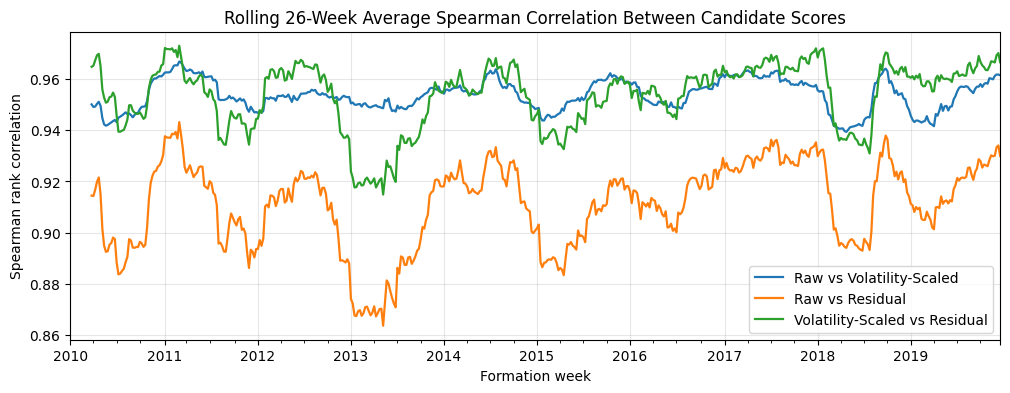

In [20]:
# ---------------------------------------------------------------------------
# Rank-information diagnostic: do candidate scores express the same idea?
# ---------------------------------------------------------------------------
def weekly_rank_correlation(
    first_score: pd.DataFrame,
    second_score: pd.DataFrame,
    minimum_assets: int,
) -> pd.Series:
    """Compute weekly cross-sectional Spearman correlations for two scores.

    Correlation is measured within each formation week because the proposed
    strategy uses the relative ranking of securities rather than score levels.
    """
    correlations = {}
    dates = research_formation_dates.intersection(first_score.index).intersection(second_score.index)

    for date in dates:
        scores = pd.concat(
            {"first": first_score.loc[date], "second": second_score.loc[date]},
            axis=1,
        ).replace([np.inf, -np.inf], np.nan).dropna()
        if len(scores) >= minimum_assets:
            correlations[date] = scores["first"].corr(scores["second"], method="spearman")

    return pd.Series(correlations, dtype=float)


# Spearman correlation is appropriate because implementation selects securities
# by rank; score magnitudes need not be comparable across definitions.
score_pairs = {
    "Raw vs Volatility-Scaled": (candidate_scores["Raw reversal"], candidate_scores["Volatility-scaled reversal"]),
    "Raw vs Residual": (candidate_scores["Raw reversal"], candidate_scores["Residual volatility-scaled reversal"]),
    "Volatility-Scaled vs Residual": (candidate_scores["Volatility-scaled reversal"], candidate_scores["Residual volatility-scaled reversal"]),
}

weekly_score_correlations = pd.DataFrame(
    {
        pair_name: weekly_rank_correlation(first, second, CONFIG.min_cross_section)
        for pair_name, (first, second) in score_pairs.items()
    }
)

# Persistent high rank correlation would indicate limited incremental ranking
# information across the alternative signal constructions.
correlation_summary = weekly_score_correlations.agg(["mean", "median", "std", "min", "max", "count"]).T
correlation_summary.columns = ["Mean", "Median", "Standard deviation", "Minimum", "Maximum", "Weeks"]

display(correlation_summary.round(4))

# The rolling view identifies whether similarity is stable or regime-dependent.
ax = weekly_score_correlations.rolling(26, min_periods=13).mean().plot(figsize=(12, 4), linewidth=1.6)
ax.set_title("Rolling 26-Week Average Spearman Correlation Between Candidate Scores")
ax.set_ylabel("Spearman rank correlation")
ax.set_xlabel("Formation week")
ax.grid(True, alpha=0.3)
plt.show()


## Extreme-Selection Overlap

Rank correlation compares the full cross-section, but the diagnostic portfolio uses only the securities in the ranked tails. With the chosen 30% leg fraction, the analysis therefore also compares the identities of securities in the highest- and lowest-score 30% groups.

The highest-score group represents recent losers and potential rebound candidates. The lowest-score group represents recent winners on the opposite side of a diagnostic spread. For any two signals $a$ and $b$:

$$
Overlap^{long}_{a,b,t}
=
\frac{|Long_{a,t} \cap Long_{b,t}|}{|Long_{a,t}|},
\qquad
Overlap^{short}_{a,b,t}
=
\frac{|Short_{a,t} \cap Short_{b,t}|}{|Short_{a,t}|}.
$$

This is an extreme-selection overlap analysis, not a realized tail-risk test: it measures whether alternative signals would lead to similar trades.


In [21]:
# ---------------------------------------------------------------------------
# Portfolio-relevance diagnostic: overlap in securities actually selected
# ---------------------------------------------------------------------------
def extreme_selection_overlap(
    first_score: pd.DataFrame,
    second_score: pd.DataFrame,
    tail_fraction: float,
    minimum_assets: int,
) -> pd.DataFrame:
    """Compare overlap in the highest- and lowest-ranked score tails each week.

    High-score securities are rebound candidates; low-score securities are the
    recent winners that would enter the opposite side of a diagnostic spread.
    """
    overlap_rows = []
    dates = research_formation_dates.intersection(first_score.index).intersection(second_score.index)

    for date in dates:
        scores = pd.concat(
            {"first": first_score.loc[date], "second": second_score.loc[date]},
            axis=1,
        ).replace([np.inf, -np.inf], np.nan).dropna()
        number_in_tail = int(np.floor(tail_fraction * len(scores)))
        if len(scores) < minimum_assets or number_in_tail < 1:
            continue

        first_ranked = scores["first"].sort_values()
        second_ranked = scores["second"].sort_values()
        first_long, second_long = set(first_ranked.tail(number_in_tail).index), set(second_ranked.tail(number_in_tail).index)
        first_short, second_short = set(first_ranked.head(number_in_tail).index), set(second_ranked.head(number_in_tail).index)

        long_overlap = len(first_long & second_long) / number_in_tail
        short_overlap = len(first_short & second_short) / number_in_tail
        overlap_rows.append(
            {
                "date": date,
                "Long-tail overlap": long_overlap,
                "Short-tail overlap": short_overlap,
                "Average-tail overlap": 0.5 * (long_overlap + short_overlap),
            }
        )

    return pd.DataFrame(overlap_rows).set_index("date")


# Tail overlap complements rank correlation: the implementable strategy trades
# only extreme winners and losers, not the complete ordering of all securities.
overlaps_by_pair = {
    pair_name: extreme_selection_overlap(first, second, CONFIG.leg_fraction, CONFIG.min_cross_section)
    for pair_name, (first, second) in score_pairs.items()
}

# High overlap means two candidate definitions would lead to similar long and
# short books, even if their numeric score scales are different.
overlap_summary = pd.DataFrame(
    {
        pair_name: {
            "Mean long-tail overlap": overlap["Long-tail overlap"].mean(),
            "Mean short-tail overlap": overlap["Short-tail overlap"].mean(),
            "Mean average-tail overlap": overlap["Average-tail overlap"].mean(),
            "Median average-tail overlap": overlap["Average-tail overlap"].median(),
            "Weeks": len(overlap),
        }
        for pair_name, overlap in overlaps_by_pair.items()
    }
).T

overlap_summary.round(4)


,Mean long-tail overlap,Mean short-tail overlap,Mean average-tail overlap,Median average-tail overlap,Weeks
Raw vs Volatility-Scaled,0.9016,0.8790,0.8903,0.8947,521.0000
Raw vs Residual,0.8315,0.8226,0.8270,0.8426,521.0000
Volatility-Scaled vs Residual,0.8804,0.8926,0.8865,0.9000,521.0000


## Interpretation Of Signal Relationships

The correlation and extreme-selection-overlap results determine whether the three candidate scores represent materially different descriptions of reversal.

- If raw reversal is less closely related to the scaled alternatives, volatility scaling or market adjustment materially changes the ordering of securities.
- If volatility-scaled and residual reversal show very high rank correlation and high extreme-selection overlap in the development sample, the residual adjustment provides limited independent information and there is little justification for passing both signals into the implementation notebook.
- If residual reversal generates meaningfully different rankings, its incremental predictive value should be assessed in the next stage of the research.

The next section tests whether these candidate signals predict next-week cross-sectional returns using information coefficients and transparent diagnostic long-short portfolios.


## Evaluation Measures

### Rank Predictiveness

For each week, the Spearman information coefficient is

$$
IC_t
=
Corr_{rank}\left(Score_{i,t}, R^W_{i,t+1}\right).
$$

A positive mean $IC$ indicates that higher reversal scores are followed by higher next-week returns. The information coefficient is an ex-post evaluation statistic, so it is calculated only for securities with both a formation-date score and a subsequently observed return.

### Economic Screening Portfolio

Portfolio membership is determined exclusively from scores observable at the end of week $t$. At every formation week, the signal screen invests equally in the highest-scoring 30% of available securities and shorts equally the lowest-scoring 30%:

$$
R^{HML}_{t+1}
=
\frac{1}{2}\overline{R}_{Long,t+1}
-
\frac{1}{2}\overline{R}_{Short,t+1}.
$$

Realized next-week returns are retrieved only after the long and short securities have been selected. A weekly diagnostic return is retained only when at least 80% of securities in each selected leg have an observed next-week return. Average realized-return coverage is reported for both legs.

Target-weight turnover is

$$
Turnover_t = \sum_i |w_{i,t}-w_{i,t-1}|.
$$

For a conservative feasibility screen, net weekly returns deduct transaction costs and an annual fixed-cost drag:

$$
R^{net}_{t+1}
=
R^{HML}_{t+1}
-
0.002 \times Turnover_t
-
\left((1.01)^{1/52}-1\right).
$$

These HML portfolios are not proposed as the final investment strategy. They are development-sample diagnostics that test whether each score contains economically meaningful information before an investable portfolio is constructed. If a candidate performs well before costs but fails after assignment-level frictions because of turnover, it may still merit implementation through a constrained, turnover-controlled model in the separate backtesting notebook.


In [22]:
# ---------------------------------------------------------------------------
# Predictive screen: IC and transparent long-short diagnostic portfolios
# ---------------------------------------------------------------------------
# This is an idea-generation test, not the final executable portfolio backtest.
# Each candidate is evaluated with the same ranking, coverage, and cost rules.
# Evaluate each candidate through the same transparent weekly sorting procedure.
formation_dates = research_formation_dates

# Store complete weekly series so signals can be compared on identical metrics.
weekly_gross_returns = {}
weekly_net_returns = {}
weekly_turnover = {}
weekly_information_coefficients = {}
weekly_realized_coverage = {}
target_positions = {}
summary_rows = []
# Costs are included as an implementation-sensitivity diagnostic; the separate
# backtesting notebook will perform the actual portfolio evaluation from 2020.
fixed_cost_weekly = (1 + CONFIG.fixed_cost_annual) ** (1 / CONFIG.weeks_per_year) - 1

# ---------------------------------------------------------------------------
# Apply one common screening protocol to every candidate signal
# ---------------------------------------------------------------------------
for signal_name, score in candidate_scores.items():
    ic_values = {}
    gross_values = {}
    positions = {}
    coverage_rows = []

    for date in formation_dates:
        # Formation-time investable universe: only contemporaneous valid scores
        # determine which names can enter the ranked portfolio.
        # The portfolio ranking universe is known at formation: it depends only on today's score.
        score_row = score.loc[date].replace([np.inf, -np.inf], np.nan).dropna()
        if len(score_row) < CONFIG.min_cross_section or score_row.nunique() < 2:
            continue

        # Mean IC measures whether higher reversal scores are monotonically
        # associated with higher next-week returns across securities.
        # IC is an ex-post predictive statistic and therefore uses matched realized outcomes.
        evaluated_cross_section = pd.concat(
            {
                "score": score_row,
                "next_week_return": forward_weekly_returns.loc[date],
            },
            axis=1,
        ).replace([np.inf, -np.inf], np.nan).dropna()

        if len(evaluated_cross_section) >= CONFIG.min_cross_section:
            ic_values[date] = stats.spearmanr(
                evaluated_cross_section["score"],
                evaluated_cross_section["next_week_return"],
            ).statistic

        # Fix membership from the score ranking alone: high-score recent losers
        # enter the long leg and low-score recent winners enter the short leg.
        n_names_per_leg = int(np.floor(CONFIG.leg_fraction * len(score_row)))
        if n_names_per_leg < 1:
            continue

        ranked_ids = score_row.sort_values().index
        short_ids = ranked_ids[:n_names_per_leg]
        long_ids = ranked_ids[-n_names_per_leg:]

        # Retrieve forward outcomes only after membership has been fixed. This
        # prevents future return availability from driving security selection.
        # Realized returns are checked only after portfolio membership is fixed.
        realized_returns = forward_weekly_returns.loc[date]
        long_returns = realized_returns.reindex(long_ids).dropna()
        short_returns = realized_returns.reindex(short_ids).dropna()
        long_coverage = len(long_returns) / n_names_per_leg
        short_coverage = len(short_returns) / n_names_per_leg
        coverage_rows.append(
            {
                "date": date,
                "Long-leg coverage": long_coverage,
                "Short-leg coverage": short_coverage,
                "Accepted week": (
                    long_coverage >= CONFIG.minimum_realized_leg_coverage
                    and short_coverage >= CONFIG.minimum_realized_leg_coverage
                ),
            }
        )
        # Require adequate realized coverage on both legs so a weekly result is
        # not driven by evaluating only securities with available outcomes.
        if (
            long_coverage < CONFIG.minimum_realized_leg_coverage
            or short_coverage < CONFIG.minimum_realized_leg_coverage
        ):
            continue

        # Equal notional long and short legs isolate the cross-sectional signal;
        # the resulting HML spread is diagnostic rather than a final portfolio.
        gross_values[date] = (
            0.5 * long_returns.mean()
            - 0.5 * short_returns.mean()
        )

        weights = pd.Series(0.0, index=score.columns)
        weights.loc[long_ids] = 0.5 / n_names_per_leg
        weights.loc[short_ids] = -0.5 / n_names_per_leg
        positions[date] = weights

    # -----------------------------------------------------------------------
    # Weekly series and implementation-sensitivity adjustment for this signal
    # -----------------------------------------------------------------------
    ic_series = pd.Series(ic_values, name=signal_name).dropna()
    gross_series = pd.Series(gross_values, name=signal_name).dropna()
    weights = pd.DataFrame(positions).T.reindex(gross_series.index).fillna(0.0)
    coverage = pd.DataFrame(coverage_rows).set_index("date")

    # Turnover and cost-adjusted returns indicate whether frequent re-ranking
    # could absorb the apparent gross effect; they are not final OOS evidence.
    turnover_series = weights.diff().abs().sum(axis=1)
    turnover_series.iloc[0] = weights.iloc[0].abs().sum()
    net_series = gross_series - CONFIG.transaction_cost * turnover_series - fixed_cost_weekly

    weekly_information_coefficients[signal_name] = ic_series
    weekly_gross_returns[signal_name] = gross_series
    weekly_net_returns[signal_name] = net_series
    weekly_turnover[signal_name] = turnover_series
    weekly_realized_coverage[signal_name] = coverage
    target_positions[signal_name] = weights

    # -----------------------------------------------------------------------
    # Summary metrics for signal selection inside the development sample
    # -----------------------------------------------------------------------
    # IC statistics assess predictive ordering; HML return, volatility and Sharpe
    # describe the magnitude and risk-adjusted strength of the diagnostic spread.
    ic_test = stats.ttest_1samp(ic_series, 0, nan_policy="omit")
    gross_test = stats.ttest_1samp(gross_series, 0, nan_policy="omit")
    gross_wealth = (1 + gross_series).cumprod()
    net_wealth = (1 + net_series).cumprod()

    # Coverage exclusions reveal whether missing subsequent returns materially
    # restrict the weeks on which the diagnostic spread can be assessed.
    summary_rows.append(
        {
            "Signal": signal_name,
            "Mean IC": ic_series.mean(),
            "IC t-stat": ic_test.statistic,
            "HML Gross annual return": (1 + gross_series).prod() ** (CONFIG.weeks_per_year / len(gross_series)) - 1,
            "HML Gross annual volatility": gross_series.std() * np.sqrt(CONFIG.weeks_per_year),
            "HML Gross Sharpe": gross_series.mean() / gross_series.std() * np.sqrt(CONFIG.weeks_per_year),
            "HML Gross return t-stat": gross_test.statistic,
            "HML Gross max drawdown": (gross_wealth / gross_wealth.cummax() - 1).min(),
            "HML Net annual return": (1 + net_series).prod() ** (CONFIG.weeks_per_year / len(net_series)) - 1,
            "HML Net Sharpe": net_series.mean() / net_series.std() * np.sqrt(CONFIG.weeks_per_year),
            "Average weekly turnover": turnover_series.mean(),
            "Average long-leg coverage": coverage["Long-leg coverage"].mean(),
            "Average short-leg coverage": coverage["Short-leg coverage"].mean(),
            "Weeks excluded for coverage": (~coverage["Accepted week"]).sum(),
            "Weeks": len(gross_series),
        }
    )

# One comparison table supports the signal choice before any 2020+ backtest.
screening_results = pd.DataFrame(summary_rows).set_index("Signal")
screening_results.round(4)


,Mean IC,IC t-stat,HML Gross annual return,HML Gross annual volatility,HML Gross Sharpe,HML Gross return t-stat,HML Gross max drawdown,HML Net annual return,HML Net Sharpe,Average weekly turnover,Average long-leg coverage,Average short-leg coverage,Weeks excluded for coverage,Weeks
Signal,,,,,,,,,,,,,,
Raw reversal,0.0566,9.2790,0.0923,0.0568,1.5845,5.0154,-0.0571,-0.0667,-1.1814,1.4173,0.9997,0.9999,0,521
Volatility-scaled reversal,0.0599,11.0459,0.1133,0.0471,2.3030,7.2898,-0.0331,-0.0512,-1.0851,1.4423,0.9996,0.9999,0,521
Residual volatility-scaled reversal,0.0533,11.3039,0.0945,0.0433,2.1087,6.6747,-0.0575,-0.0661,-1.5522,1.4310,0.9996,1.0000,0,521


## Development-Sample Signal Comparison

The selection decision is based first on predictive evidence and gross diagnostic behavior during 2010-2019, and second on the implementation pressure indicated by turnover and required costs. A simple candidate is preferred over a more complex specification unless the additional transformation produces a meaningful improvement in the development sample.


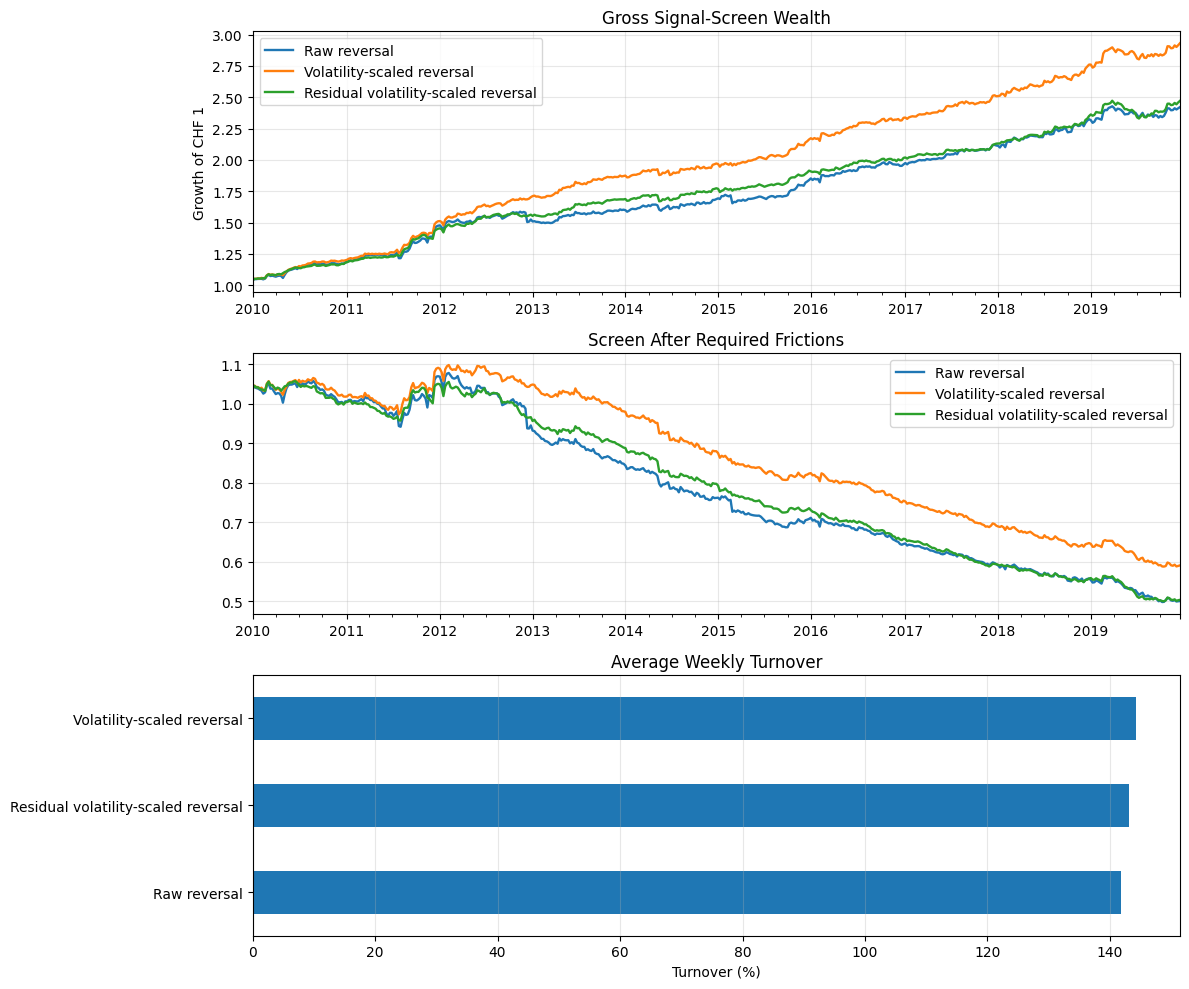

In [23]:
# ---------------------------------------------------------------------------
# Visual comparison of candidate signals within the development sample
# ---------------------------------------------------------------------------
# These curves summarize idea-screen evidence only; they are not holdout
# backtest results and should not be interpreted as investable performance.
gross_return_frame = pd.DataFrame(weekly_gross_returns)
net_return_frame = pd.DataFrame(weekly_net_returns)
turnover_frame = pd.DataFrame(weekly_turnover)
ic_frame = pd.DataFrame(weekly_information_coefficients)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Gross wealth isolates signal strength before implementation frictions.
(1 + gross_return_frame).cumprod().plot(ax=axes[0], linewidth=1.7)
axes[0].set_title("Gross Signal-Screen Wealth")
axes[0].set_ylabel("Growth of CHF 1")
axes[0].grid(True, alpha=0.3)

# Net wealth stresses sensitivity to the stated simplified cost assumptions.
(1 + net_return_frame).cumprod().plot(ax=axes[1], linewidth=1.7)
axes[1].set_title("Screen After Required Frictions")
axes[1].grid(True, alpha=0.3)

# Turnover identifies candidates whose apparent edge relies on excessive trading.
(100 * turnover_frame.mean()).sort_values().plot(kind="barh", ax=axes[2], color="C0")
axes[2].set_title("Average Weekly Turnover")
axes[2].set_xlabel("Turnover (%)")
axes[2].grid(True, axis="x", alpha=0.3)

fig.tight_layout()
plt.show()


## Development-Sample Stability And Extreme-Return Sensitivity

The selected candidate is examined separately across the early and later halves of the 2010-2019 development period. This is an internal stability check, not an out-of-sample backtest. The return-cap exercise is also diagnostic only: it tests whether a small number of extreme realized price movements dominate the signal-selection conclusion and is not part of the eventual implemented strategy.


In [24]:
# ---------------------------------------------------------------------------
# Selected idea: stability within the sealed development sample
# ---------------------------------------------------------------------------
# The selected ranking rule is now examined for persistence and sensitivity;
# portfolio backtesting is intentionally deferred to the 2020+ notebook.
selected_signal = "Volatility-scaled reversal"
selected_gross = weekly_gross_returns[selected_signal]
selected_ic = weekly_information_coefficients[selected_signal]
selected_weights = target_positions[selected_signal]

# Compare two non-overlapping subperiods to assess whether the signal is a
# persistent development-sample pattern rather than a single-era observation.
subperiods = {
    "2010-2014": ("2010-01-01", "2014-12-31"),
    "2015-2019": ("2015-01-01", "2019-12-31"),
}
stability_rows = []
for period_name, (start, end) in subperiods.items():
    period_returns = selected_gross.loc[start:end]
    period_ic = selected_ic.loc[start:end]
    stability_rows.append(
        {
            "Period": period_name,
            "Annualized gross return": (1 + period_returns).prod() ** (CONFIG.weeks_per_year / len(period_returns)) - 1,
            "Annualized volatility": period_returns.std() * np.sqrt(CONFIG.weeks_per_year),
            "Gross Sharpe": period_returns.mean() / period_returns.std() * np.sqrt(CONFIG.weeks_per_year),
            "Mean IC": period_ic.mean(),
            "Weeks": len(period_returns),
        }
    )

stability_table = pd.DataFrame(stability_rows).set_index("Period")

# ---------------------------------------------------------------------------
# Tail sensitivity: hold rankings fixed and moderate extreme realized outcomes
# ---------------------------------------------------------------------------
# Keep the original holdings fixed and cap only subsequent realized stock returns.
# This is a diagnostic robustness check, not a replacement for observed results.
selected_forward_returns = forward_weekly_returns.reindex(
    index=selected_weights.index,
    columns=selected_weights.columns,
)
capped_forward_returns = selected_forward_returns.clip(
    lower=-CONFIG.realized_weekly_return_cap,
    upper=CONFIG.realized_weekly_return_cap,
)
capped_selected_gross = (selected_weights * capped_forward_returns).sum(axis=1)
extreme_held_observations = (
    (selected_weights != 0)
    & (selected_forward_returns.abs() > CONFIG.realized_weekly_return_cap)
).to_numpy().sum()

sensitivity_table = pd.DataFrame(
    {
        "Annualized gross return": [
            (1 + selected_gross).prod() ** (CONFIG.weeks_per_year / len(selected_gross)) - 1,
            (1 + capped_selected_gross).prod() ** (CONFIG.weeks_per_year / len(capped_selected_gross)) - 1,
        ],
        "Annualized volatility": [
            selected_gross.std() * np.sqrt(CONFIG.weeks_per_year),
            capped_selected_gross.std() * np.sqrt(CONFIG.weeks_per_year),
        ],
        "Gross Sharpe": [
            selected_gross.mean() / selected_gross.std() * np.sqrt(CONFIG.weeks_per_year),
            capped_selected_gross.mean() / capped_selected_gross.std() * np.sqrt(CONFIG.weeks_per_year),
        ],
    },
    index=["Observed returns", "Returns capped at +/-50% for diagnostic"],
)

display(stability_table.round(4))
display(sensitivity_table.round(4))
print(f"Selected holdings followed by an absolute weekly return above 50%: {extreme_held_observations}")


,Annualized gross return,Annualized volatility,Gross Sharpe,Mean IC,Weeks
Period,,,,,
2010-2014,0.1448,0.0543,2.5194,0.0719,261
2015-2019,0.0826,0.0383,2.0921,0.0478,260


,Annualized gross return,Annualized volatility,Gross Sharpe
Observed returns,0.1133,0.0471,2.3030
Returns capped at +/-50% for diagnostic,0.1067,0.0398,2.5713


Selected holdings followed by an absolute weekly return above 50%: 31


## Signal Selection And Handoff To The Backtesting Notebook

This notebook confines the signal-selection decision to the **January 2010 through December 2019 development period**. Candidate scores are compared using predictive information coefficients, transparent diagnostic portfolios with 30% long and short tails, simplicity, and redundancy relative to the alternative formulations.

Based on the displayed development-sample evidence, the score selected and frozen for implementation is volatility-scaled weekly reversal:

$$
s_{i,t}
=
-\frac{R^W_{i,t}}{\sigma^W_{i,t}}.
$$

The direct long-short screen is not the final strategy. Its purpose is to identify whether the signal has economic content and whether trading frictions motivate a more controlled implementation. The companion backtesting notebook will implement only the frozen signal beginning on `2020-01-01`, using the correct `lag=0` timing convention, and will contain final tradability filters, Black-Litterman portfolio construction, constraints, turnover control, required-cost reporting, and comparison against the SPI.

No performance result from 2020 onward is used in this notebook's reported signal-selection analysis.
